# Causal Analysis Pipeline for Time Series

This notebook demonstrates the causal discovery and effect estimation pipeline for time series data. It shows how to:

1. Create a causal model
2. Generate synthetic data
3. Run causal discovery with PCMCI
4. Estimate causal effects
5. Evaluate and visualize results
6. Run parameter studies

## Setup

First, import the necessary modules:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tigramite import plotting as tp
from tigramite.pcmci import PCMCI

# Import our custom modules
from causal_core import (
    create_causal_model,
    create_stable_model,
    generate_dataset,
    run_causal_discovery,
    estimate_all_effects,
    compare_adjustment_sets,
    get_optimal_adjustment_set,
    get_groundtruth
)

from causal_evaluation import (
    run_pipeline,
    load_dataset,
    load_discovery_results,
    load_effect_results,
    load_all_results_to_dataframe,
    calculate_metrics
)

from causal_visualization import (
    plot_causal_graph,
    plot_ts_graph,
    plot_graph_comparison,
    plot_effect_histogram,
    plot_effect_density,
    plot_multimodality_test,
    plot_effect_comparison,
    plot_error_comparison,
    plot_metrics_comparison,
    plot_timing_comparison
)

# For pretty plotting
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Create Causal Model

First, we'll create a structural causal model (SCM) that defines the causal relationships between variables.

In [2]:
# Set parameters
n_vars = 4  # Number of variables
auto_coeff = 0.  # Autocorrelation coefficient
cross_coeff = 0.5  # Cross-link coefficient
noise_sigma = 100.  # Noise standard deviation

# Create a stable causal model
links, noises = create_causal_model(
#    graph_structure = links,
    n_vars=n_vars, 
    auto_coeff=auto_coeff, 
    cross_coeff=cross_coeff, 
    noise_sigma=noise_sigma
)

# Print the links
print("Links in the causal model:")
for var, parents in links.items():
    print(f"Variable X{var+1} has parents:")
    for parent in parents:
        parent_var, parent_lag = parent[0]
        coeff = parent[1]
        func = parent[2].__name__ if hasattr(parent[2], '__name__') else str(parent[2])
        print(f"  X{parent_var+1}(t{parent_lag}) with coefficient {coeff:.4f} and function {func}")

linkString =""
for var, parents in links.items():
    linkString += f"Variable X{var+1} has parents:" +"\n"
    for parent in parents:
        parent_var, parent_lag = parent[0]
        coeff = parent[1]
        func = parent[2].__name__ if hasattr(parent[2], '__name__') else str(parent[2])
        linkString += f"  X{parent_var+1}(t{parent_lag}) with coefficient {coeff:.4f} and function {func}" +"\n"

Links in the causal model:
Variable X1 has parents:
  X1(t-1) with coefficient 0.0000 and function <lambda>
  X3(t-1) with coefficient 0.5000 and function <lambda>
Variable X2 has parents:
  X2(t-1) with coefficient 0.0000 and function <lambda>
  X1(t-1) with coefficient 0.5000 and function <lambda>
Variable X3 has parents:
  X3(t-1) with coefficient 0.0000 and function <lambda>
Variable X4 has parents:
  X4(t-1) with coefficient 0.0000 and function <lambda>
  X1(t-1) with coefficient 0.5000 and function <lambda>
  X2(t-1) with coefficient 0.5000 and function <lambda>
  X3(t-2) with coefficient 0.5000 and function <lambda>


In [3]:
print(linkString)


Variable X1 has parents:
  X1(t-1) with coefficient 0.0000 and function <lambda>
  X3(t-1) with coefficient 0.5000 and function <lambda>
Variable X2 has parents:
  X2(t-1) with coefficient 0.0000 and function <lambda>
  X1(t-1) with coefficient 0.5000 and function <lambda>
Variable X3 has parents:
  X3(t-1) with coefficient 0.0000 and function <lambda>
Variable X4 has parents:
  X4(t-1) with coefficient 0.0000 and function <lambda>
  X1(t-1) with coefficient 0.5000 and function <lambda>
  X2(t-1) with coefficient 0.5000 and function <lambda>
  X3(t-2) with coefficient 0.5000 and function <lambda>



### Visualize the True Causal Graph

Let's visualize the causal structure of our model:

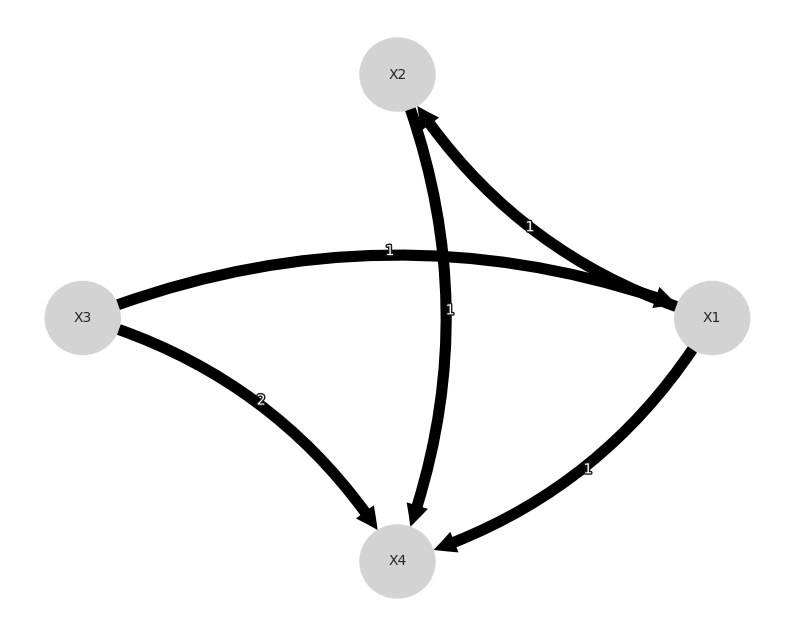

In [4]:


# Get adjacency matrix from links
true_graph = PCMCI.get_graph_from_dict(links)

# Define variable names
var_names = [f'X{i+1}' for i in range(n_vars)]

# Plot the graph
fig = plot_causal_graph(
    graph=true_graph,
    var_names=var_names,
    title="True Causal Graph"
)


#plt.savefig('dag.png')
#plt.close()
plt.show()

## 2. Generate Data

Next, we'll generate synthetic time series data from our SCM:

In [5]:
# Set parameters
T = 500  # Time series length
seed = None  # Random seed for reproducibility

# Generate dataset
dataset, gen_time = generate_dataset(
    links=links, 
    T=T, 
    noises=noises, 
    seed=seed
)

print(f"Generated time series of length {T} for {n_vars} variables in {gen_time:.4f} seconds")


Generated time series of length 500 for 4 variables in 0.0225 seconds


### Visualize the Data

Let's plot the generated time series:

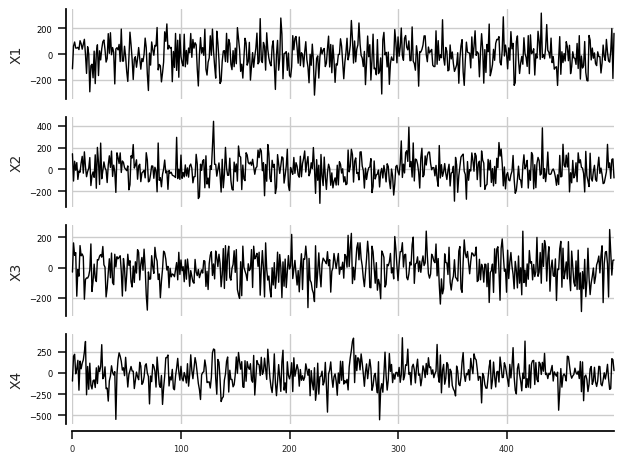

In [6]:
tp.plot_timeseries(dataset); 
#plt.savefig('data.png')
#plt.close()

In [12]:
print(dataset)

In [7]:
# Define the causal effect to estimate
X = (0, -2)  # Variable X1 with lag -3 (t-3)
Y = (3, 0)   # Variable X4 at current time (t)
get_groundtruth(links,X,Y)
print(2*auto_coeff*cross_coeff+ cross_coeff**2)
print(get_groundtruth(links,X,Y,None)[0])
print(get_groundtruth(links,X,Y,noises)[0])
print(noises)

0.25
0.25
0.25
[<function create_causal_model.<locals>.<listcomp>.<lambda> at 0x74923535c4c0>, <function create_causal_model.<locals>.<listcomp>.<lambda> at 0x74923535c550>, <function create_causal_model.<locals>.<listcomp>.<lambda> at 0x74923535c5e0>, <function create_causal_model.<locals>.<listcomp>.<lambda> at 0x74923535c670>]


## 3. Run Causal Discovery

Now we'll run causal discovery to infer the causal structure from the data:

In [8]:
# Set parameters
pc_alpha = 0.05  # Significance level
tau_max = 4  # Maximum time lag
n_boot = 5  # Number of bootstrap samples

# Run causal discovery
discovery_results, discovery_times = run_causal_discovery(
    dataset=dataset, 
    pc_alpha=pc_alpha, 
    tau_max=tau_max, 
    n_boot=n_boot
)

print(f"PCMCI discovery completed in {discovery_times['pcmci']:.4f} seconds")
print(f"Bootstrap discovery completed in {discovery_times['bootstrap']:.4f} seconds")

PCMCI discovery completed in 0.2431 seconds
Bootstrap discovery completed in 1.6204 seconds


### Visualize the Discovered Graphs

Let's compare the true graph with the discovered graphs:

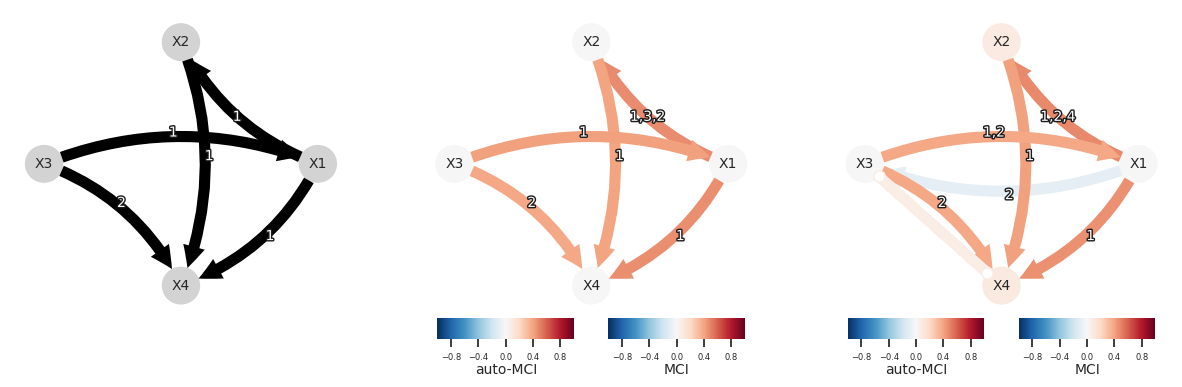

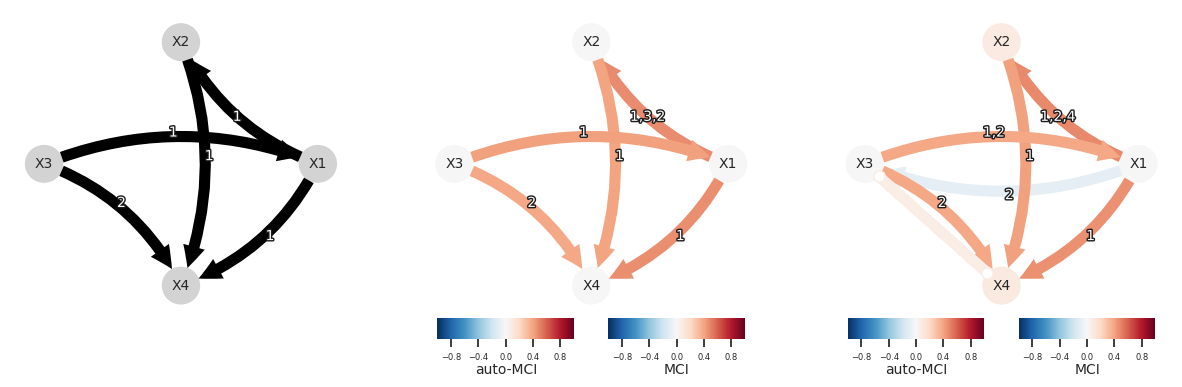

In [9]:
# Extract graphs
pcmci_graph = discovery_results['pcmci']['graph']
pcmci_val_matrix = discovery_results['pcmci']['val_matrix']
bagged_graph = discovery_results['bagged_graph']
bagged_val_matrix = discovery_results['bootstrap']['summary_results']['val_matrix_mean']
# Compare graphs
graphs_dict = {
    "True Graph": true_graph,
    "PCMCI Graph": (pcmci_graph, pcmci_val_matrix),
    "Bagged Graph": (bagged_graph,bagged_val_matrix)
}

plot_graph_comparison(graphs_dict, var_names=var_names)
#plt.savefig('graph_compare_T300.png')

## 4. Estimate Causal Effects

Now let's estimate the causal effect between two variables:

In [10]:
# Define the causal effect to estimate
X = (0, -2)  # Variable X1 with lag -3 (t-3)
Y = (3, 0)   # Variable X4 at current time (t)
adjustment_sets = compare_adjustment_sets(discovery_results, X, Y, true_graph, var_names)
 
# # Print results
print(adjustment_sets)
print(f"Causal Effect: X{X[0]+1}(t{X[1]}) → X{Y[0]+1}(t{Y[1]})")
print("=" * 50)
for graph_name, result in adjustment_sets.items():
    print(f"\n{graph_name}:")
    if isinstance(result["readable_set"], list):
        print(f"  Optimal Adjustment Set: {', '.join(result['readable_set'])}")
    else:
        print(f"  {result['readable_set']}")

{'PCMCI Graph': {'optimal_set': [(0, -4), (0, -3), (2, -2), (0, -1)], 'readable_set': ['X1(t-4)', 'X1(t-3)', 'X3(t-2)', 'X1(t-1)']}, 'Bagged Graph': {'optimal_set': [(2, -2), (1, -4), (0, -3), (0, -5), (3, -4), (0, -1)], 'readable_set': ['X3(t-2)', 'X2(t-4)', 'X1(t-3)', 'X1(t-5)', 'X4(t-4)', 'X1(t-1)']}, 'True Graph': {'optimal_set': [(2, -2), (0, -1)], 'readable_set': ['X3(t-2)', 'X1(t-1)']}}
Causal Effect: X1(t-2) → X4(t0)

PCMCI Graph:
  Optimal Adjustment Set: X1(t-4), X1(t-3), X3(t-2), X1(t-1)

Bagged Graph:
  Optimal Adjustment Set: X3(t-2), X2(t-4), X1(t-3), X1(t-5), X4(t-4), X1(t-1)

True Graph:
  Optimal Adjustment Set: X3(t-2), X1(t-1)


In [11]:
# Estimate causal effects using all methods
effect_results, effect_times = estimate_all_effects(
    discovery_results=discovery_results, 
    dataframe=dataset, 
    X=X, Y=Y, 
    links=links, 
    noises=noises
)

# Print results
print(f"Causal effect from X{X[0]+1}(t{X[1]}) to X{Y[0]+1}(t{Y[1]}):\n")
print(f"True effect: {effect_results['true_effect']:.4f}")
print(f"PCMCI estimate: {effect_results['pcmci_effect']:.4f} (estimated in {effect_times['pcmci_effect']:.4f} s)")
print(f"Bagged estimate: {effect_results['bagged_effect']:.4f} (estimated in {effect_times['bagged_effect']:.4f} s)")
print(f"True graph estimate: {effect_results['true_graph_effect']:.4f} (estimated in {effect_times['bagged_effect']:.4f} s)")
print(f"\nBootstrap statistics (estimated in {effect_times['bootstrap_effects']:.4f} s):")
print(f"  Mean: {effect_results['bootstrap_stats']['mean']:.4f}")
print(f"  Std Dev: {effect_results['bootstrap_stats']['std']:.4f}")
print(f"  95% CI: [{effect_results['bootstrap_stats']['ci_lower']:.4f}, {effect_results['bootstrap_stats']['ci_upper']:.4f}]")

Causal effect from X1(t-2) to X4(t0):

True effect: 0.2500
PCMCI estimate: 0.2560 (estimated in 1.8617 s)
Bagged estimate: 0.2592 (estimated in 17.2905 s)
Bagged estimate: 0.2530 (estimated in 17.2905 s)

Bootstrap statistics (estimated in 123.2471 s):
  Mean: 0.2643
  Std Dev: 0.0149
  95% CI: [0.2459, 0.2828]


In [12]:
fail here

SyntaxError: invalid syntax (1194020039.py, line 1)

### Visualize Bootstrap Distribution

Let's look at the distribution of bootstrap effect estimates:

In [ ]:
# Plot histogram
plot_effect_histogram(
    bootstrap_effects=effect_results['bootstrap_effects'],
    true_effect=effect_results['true_effect']
)

In [ ]:
# Plot density
plot_effect_density(
    bootstrap_effects=effect_results['bootstrap_effects'],
    true_effect=effect_results['true_effect']
)

In [ ]:
# Test for multimodality
fig, is_multimodal = plot_multimodality_test(
    bootstrap_effects=effect_results['bootstrap_effects']
)

print(f"Is the bootstrap distribution multimodal? {is_multimodal}")

In [ ]:
output_dir = "single_run_results"
os.makedirs(output_dir, exist_ok=True)

## 5. Run Complete Pipeline

Now, let's run the full pipeline in one go:

In [ ]:
# Create output directory
output_dir = "single_run_results"
os.makedirs(output_dir, exist_ok=True)

# Define effect pairs to estimate
effect_pairs = [
    ((0, -2), (3, 0)),  # X1(t-3) → X4(t)
    ((0, -1), (0, 0))  # X1(t-1) → X1(t)
]

# Run pipeline
pipeline_results = run_pipeline(
    auto_coeff=0.8,
    cross_coeff=0.5,
    noise_sigma=0.5,
    n_vars=4,
    T=1000,
    pc_alpha=0.05,
    tau_max=5,
    n_boot=10,
    effect_pairs=effect_pairs,
    output_dir=output_dir,
    seed=42
)

print(f"Pipeline completed in {pipeline_results['timings']['total']:.2f} seconds")
print("Effect results:")
for effect_key, effects in pipeline_results['effects'].items():
    print(f"\n{effect_key}:")
    print(f"  True effect: {effects['true_effect']:.4f}")
    print(f"  PCMCI estimate: {effects['pcmci_effect']:.4f}")
    print(f"  Bagged estimate: {effects['bagged_effect']:.4f}")
    print(f"  Bootstrap mean: {effects['bootstrap_stats']['mean']:.4f}")

### Load and Analyze Results

Let's load the saved results and analyze them:

In [ ]:
# Create a DataFrame with all effect results
results_df = pd.DataFrame()

for effect_key, effects in pipeline_results['effects'].items():
    row = {
        'effect_key': effect_key,
        'true_effect': effects['true_effect'],
        'pcmci_effect': effects['pcmci_effect'],
        'bagged_effect': effects['bagged_effect'],
        'bootstrap_mean': effects['bootstrap_stats']['mean'],
        'bootstrap_std': effects['bootstrap_stats']['std'],
        'bootstrap_ci_lower': effects['bootstrap_stats']['ci_lower'],
        'bootstrap_ci_upper': effects['bootstrap_stats']['ci_upper']
    }
    
    # Add errors
    row['pcmci_error'] = row['pcmci_effect'] - row['true_effect']
    row['bagged_error'] = row['bagged_effect'] - row['true_effect']
    row['bootstrap_error'] = row['bootstrap_mean'] - row['true_effect']
    
    row['pcmci_abs_error'] = abs(row['pcmci_error'])
    row['bagged_abs_error'] = abs(row['bagged_error'])
    row['bootstrap_abs_error'] = abs(row['bootstrap_error'])
    
    row['pcmci_squared_error'] = row['pcmci_error'] ** 2
    row['bagged_squared_error'] = row['bagged_error'] ** 2
    row['bootstrap_squared_error'] = row['bootstrap_error'] ** 2
    
    # Add CI coverage
    row['ci_covers_true'] = (row['true_effect'] >= row['bootstrap_ci_lower']) and \
                           (row['true_effect'] <= row['bootstrap_ci_upper'])

    results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

# Display the DataFrame
results_df

In [ ]:

# Calculate performance metrics
#metrics = calculate_metrics(results_df)
#metrics

In [ ]:
# Plot effect comparison
plot_effect_comparison(results_df)

In [ ]:
# Plot error comparison
plot_error_comparison(results_df, error_type='abs')

## 6. Parameter Study

Let's run a parameter study to see how changing a parameter affects the results:

In [ ]:

# Import parameter study functions
from causal_evaluation import run_parameter_study

# Define parameters
param_values = [0.5, 0.7, 0.9]  # Values to test
output_dir = "auto_study_results"

# Set base parameters
base_params = {
    'auto_coeff': 0.8,
    'cross_coeff': 0.5,
    'noise_sigma': 0.5,
    'n_vars': 4,
    'T': 300,  # Smaller dataset for faster execution
    'pc_alpha': 0.05,
    'tau_max': 5,
    'n_boot': 50,  # Fewer bootstrap samples for faster execution
    'effect_pairs': [((0, -3), (3, 0))]  # Focus on one effect pair
}

# Run study (this might take a while)
study_results = run_parameter_study(
    param_name='auto',  # Study autocorrelation
    param_values=param_values,
    base_params=base_params,
    output_dir=output_dir,
    seed=123
)

print(f"Parameter study completed. Results saved in {output_dir}")


### Load Parameter Study Results

Now let's load and analyze the parameter study results:

In [ ]:
# Load all results to DataFrame
study_df = load_all_results_to_dataframe(output_dir)

# View the loaded data
study_df.head()

In [ ]:
# Calculate metrics for each parameter value
metrics_by_param = calculate_metrics(study_df, group_by='param_value')
metrics_by_param

In [ ]:
# Plot effect comparison across parameter values
plot_effect_comparison(study_df, param_name='auto')

In [ ]:
# Plot error comparison across parameter values
plot_error_comparison(study_df, param_name='auto', error_type='abs')

In [ ]:
# Plot metrics comparison
plot_metrics_comparison(metrics_by_param, param_name='param_value', metric='mae')

In [ ]:
# Plot timing comparison
plot_timing_comparison(study_df, param_name='param_value')

## 7. Full Parameter Study (Optional)

For a comprehensive analysis, you can run a full parameter study that varies autocorrelation, cross-link strength, and noise level. This is commented out as it can take a long time to run:

In [ ]:
#Uncomment to run full parameter study
from causal_evaluation import run_full_study
# Define parameter values to test
auto_values = np.linspace(0.1,.9,9)
cross_values = np.linspace(0.1,.9,9)
noise_values = np.linspace(0.1,2.,9)
# Set base parameters
base_params = {
    'auto_coeff': 0.5,
    'cross_coeff': 0.5,
    'noise_sigma': 0.5,
    'n_vars': 4,
    'T': 500,  # Smaller dataset for faster execution
    'pc_alpha': 0.05,
    'tau_max': 5,
    'n_boot': 30,  # Fewer bootstrap samples for faster execution
    'effect_pairs': [((0, -2), (3, 0))]  # Focus on one effect pair
}
# Run full study
full_results = run_full_study(
    auto_values=auto_values,
    cross_values=cross_values,
    noise_values=noise_values,
    base_params=base_params,
    output_dir="full_study_results",
    seed=None
)

## Conclusion

In this notebook, we've demonstrated a complete pipeline for causal discovery and effect estimation with time series data. We've shown how to:

1. Create a causal model
2. Generate synthetic data
3. Run causal discovery with PCMCI and bootstrapping
4. Estimate causal effects using different methods
5. Evaluate and visualize results
6. Run parameter studies to assess how model parameters affect estimation

This framework can be extended to real-world data and more complex causal structures. The modular design allows for customization and extension to suit specific needs.